## Regular water waves interacting with thin-wall cylindrical OWC device - Frequency-Domain BEM

**3D Boundary Element Method for Linear Wave Propagation**

This tutorial presents the implementation of a 3D BEM to simulate the propagation of regular linear water waves interacting with a thin-wall cylindrical OWC device.

The formulation is based on:
- Linear potential flow theory  
- Frequency-domain (time-harmonic) analysis  
- Boundary integral equation formulation  

Objectives of this notebook:
- Introduce the workflow and structure of the code  
- Solve the wave structure interaction problem
- Validate the OWC performance with Evans and Porter (1997).

Ref: Evans, D. V., and Porter, R. (November 1, 1997). "Efficient Calculation of Hydrodynamic Properties of OWC-Type Devices." ASME. J. Offshore Mech. Arct. Eng. November 1997; 119(4): 210–218. https://doi.org/10.1115/1.2829098

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

import meshio
import numpy as np

from MAIN_MESH import MAIN_MESH
    
from BEM_UTILS.constants import gravity, rho

from BEM_UTILS.PROCESS_MESH import PROCESS_MESH
from BEM_UTILS.PROCESS_CONNECTIVITY import PROCESS_CONNECTIVITY
from BEM_UTILS.IDENTIFY_BOUNDARY_ELEMENTS import IDENTIFY_BOUNDARY_ELEMENTS
from BEM_UTILS.COS_DIR import COS_DIR

from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.TRILOC6 import TRILOC6
from MATRICES.FUNDA6 import FUNDA6

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_IN import BC_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_OUT import BC_FAR_FIELD_OUT

from BOUNDARY_CONDITIONS.BC_INTERFACE import BC_INTERFACE

from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING
from BOUNDARY_CONDITIONS.BC_RADIATION import BC_RADIATION

from BOUNDARY_CONDITIONS.INT_FLUX_FS_S import INT_FLUX_FS_S
from BOUNDARY_CONDITIONS.INT_FLUX_FS_R import INT_FLUX_FS_R

from BEM_UTILS.FX_FUNCTION import FX_FUNCTION
from BEM_UTILS.ENERGY_FLUX import ENERGY_FLUX
from BEM_UTILS.NODES_FS import NODES_FS

from BEM_UTILS.MATCHING_INTERFACES import MATCHING_INTERFACES

from BEM_UTILS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

**2.1 Physical domain and geometry parameters**

In [2]:
# FLUID DOMAIN
DEPTH         = 8.00;
WIDTH_CHANNEL = 20;

# Structure geometry 
RADIUS       = (1/2)*DEPTH
DRAFT        = (1/2)*DEPTH

# Length of the incident region
LX = 2*DEPTH

# Distance from the exterior radius to the square that encloses the OWC 
DX = (1/16)*DEPTH

# Center of OWC  
LOC_STRUCT_X = [LX + RADIUS + DX]
LOC_STRUCT_Y = [0.00]

# Physical model
N_STRUCT = 1;

# Numerical model
NUM_OF_REG = 4;

In [3]:
# GMSH mesh
MAIN_MESH(DEPTH,WIDTH_CHANNEL,RADIUS,DRAFT,LX,DX,LOC_STRUCT_X,LOC_STRUCT_Y)

**2.2 Wave parameters and frequency range**

In [4]:
# Number of frequencies / wave cases
ttmax = 50

# Dimensionless wavenumber (k*h)
kh = np.linspace(1.0, 2.5, ttmax)

# Wave height
Wave_height = 0.1

**3. Mesh**

In [5]:
# Read the Gmsh file and extract node PROCESS_CONNECTIVITY and element connectivity
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("REGION_INC.msh")
MESH_1_POS, MESH_1_QUADS9 = PROCESS_MESH("REGION_OWC.msh")
MESH_2_POS, MESH_2_QUADS9 = PROCESS_MESH("REGION_OWC_CHAMBER.msh")
MESH_3_POS, MESH_3_QUADS9 = PROCESS_MESH("REGION_TRA.msh")

In [6]:
# Quadrilateral elements are used; each element has 9 nodes ordered counterclockwise.
NCONEC = 9;

In [7]:
# Initialize arrays to store the number of nodes (N) and elements (NE) per region
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [8]:
# Extract the number of nodes, number of elements, and reorder element connectivity
# to match the node orientation required by the BEM formulation
N[0] ,  NE[0] ,  KCONEC_0 = PROCESS_CONNECTIVITY(MESH_0_POS , MESH_0_QUADS9)
N[1] ,  NE[1] ,  KCONEC_1 = PROCESS_CONNECTIVITY(MESH_1_POS , MESH_1_QUADS9)
N[2] ,  NE[2] ,  KCONEC_2 = PROCESS_CONNECTIVITY(MESH_2_POS , MESH_2_QUADS9)
N[3] ,  NE[3] ,  KCONEC_3 = PROCESS_CONNECTIVITY(MESH_3_POS , MESH_3_QUADS9)

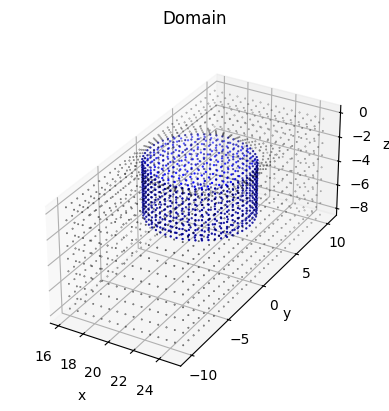

In [9]:
# Domain visulization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_1_POS[:,0],
    MESH_1_POS[:,1],
    MESH_1_POS[:,2],
    c='k',
    s=0.1
)

ax.scatter(
    MESH_2_POS[:,0],
    MESH_2_POS[:,1],
    MESH_2_POS[:,2],
    c='b',
    s=0.5
)

# DOMAIN LIMITS
x_min, x_max = np.min(MESH_1_POS[:,0]), np.max(MESH_1_POS[:,0])
y_min, y_max = np.min(MESH_1_POS[:,1]), np.max(MESH_1_POS[:,1])
z_min, z_max = np.min(MESH_1_POS[:,2]), np.max(MESH_1_POS[:,2])

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Domain")

# Aspect ratio
ax.set_box_aspect([Lx, Ly, Lz])

plt.show()

In [10]:
# Identify elements belonging to each boundary and compute their outward normal vectors
REF_R0 , NORMAL_0 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_0 , MESH_0_POS , NE[0], N_STRUCT)
REF_R1 , NORMAL_1 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_1 , MESH_1_POS , NE[1], N_STRUCT)
REF_R2 , NORMAL_2 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_2 , MESH_2_POS , NE[2], N_STRUCT)
REF_R3 , NORMAL_3 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_3 , MESH_3_POS , NE[3], N_STRUCT)

In [11]:
# Concatenate normal array
NORMAL = np.vstack((NORMAL_0, NORMAL_1, NORMAL_2, NORMAL_3))

In [12]:
# Total number of nodes and elements
N_total  = np.sum(N)
NE_total = np.sum(NE)

In [13]:
# Concatenate local connectivity matrices and map local node indices to the global coordinate system
KCON_N_0  = KCONEC_0
KCON_N_01 = KCONEC_1 + N[0]
KCON_N_02 = KCONEC_2 + N[0] + N[1]
KCON_N_03 = KCONEC_3 + N[0] + N[1] + N[2]

KCONEC = np.hstack((KCON_N_0, KCON_N_01, KCON_N_02, KCON_N_03))

**4. Influence matrices**

In [14]:
# Form H and B matrices for each region
H0 , G0 = GHMAT6(MESH_0_POS , NCONEC , KCONEC_0 , NE[0] , N[0] , DEPTH);
H1 , G1 = GHMAT6(MESH_1_POS , NCONEC , KCONEC_1 , NE[1] , N[1] , DEPTH);
H2 , G2 = GHMAT6(MESH_2_POS , NCONEC , KCONEC_2 , NE[2] , N[2] , DEPTH);
H3 , G3 = GHMAT6(MESH_3_POS , NCONEC , KCONEC_3 , NE[3] , N[3] , DEPTH);

In [15]:
# Assembling the H and G matrices
from scipy.linalg import block_diag
H = np.zeros((N_total, N_total), dtype=np.complex128)

H = block_diag(H0, H1, H2, H3)

G = np.zeros((N_total, NCONEC * NE_total), dtype=np.complex128)

G = block_diag(G0, G1, G2, G3)

In [16]:
# Identify matching nodes across interfaces. 
# Provides a mapping of local node indices, element indices, and local ordering (1-9).
# Note: STORE_NODE_out and STORE_NODE_in maintain a 1-to-1 row correspondence.
[STORE_NODE_R0_out, STORE_NODE_R1_in] = MATCHING_INTERFACES(REF_R0['OUT'] , MESH_0_POS , KCONEC_0 , REF_R1['IN'] , MESH_1_POS , KCONEC_1 , NCONEC)
[STORE_NODE_R1_out, STORE_NODE_R3_in] = MATCHING_INTERFACES(REF_R1['OUT'] , MESH_1_POS , KCONEC_1 , REF_R3['IN'] , MESH_3_POS , KCONEC_3 , NCONEC)

[STORE_NODE_OWC_out, STORE_NODE_OWC_in] = MATCHING_INTERFACES(REF_R1['MATCH_OWC'] , MESH_1_POS , KCONEC_1 , REF_R2['MATCH_OWC'] , MESH_2_POS , KCONEC_2 , NCONEC)

**5. Frequency loop and boundary condition application**

In [17]:
# Preallocate arrays for reflection/transmission coefficients
CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

Kh = np.zeros(ttmax)

# Preallocate OWC terms
mu     = np.zeros(ttmax)
nu     = np.zeros(ttmax)
eta    = np.zeros(ttmax)

# Dictionary to store wave properties for each frequency case
WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# Frequency loop
for tt in range(ttmax):

    print(tt + 1)

    # Compute wavenumber from dimensionless kh
    k = kh[tt] / DEPTH

    # Linear wave dispersion relation → wave period
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # Wave frequency and angular frequency
    f = 1.0 / T
    omega = 2*np.pi*f

    # Wave amplitude
    Amp = Wave_height / 2

    # Dispersion relation for surface gravity waves in deep water * DEPTH
    Kh[tt] = (omega**2/gravity)*DEPTH

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Backup original system matrices before applying BCs
    A = H.copy()
    B = G.copy()

    # ------------------------
    # Apply boundary conditions, Scattering (S) and Radiation (R) problem
    # ------------------------

    # Free-surface boundary condition
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC, NE, 0)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R1["FS"], KCONEC, NE, 1)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R3["FS"], KCONEC, NE, 3)

    # Internal free surface
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R2["INT_FS"], KCONEC, NE, 2)

    # Radiation boundary conditions at inlet and outlet (far field)
    A = BC_FAR_FIELD_IN (A, B, k, NCONEC,  NORMAL, REF_R0["IN"],    KCONEC, NE, 0)
    A = BC_FAR_FIELD_OUT(A, B, k, NCONEC,  NORMAL, REF_R3["OUT"],   KCONEC, NE, 3)

    # Interface boundary conditions
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R0_out, STORE_NODE_R1_in, N, NE, 0, 1)
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R1_out, STORE_NODE_R3_in, N, NE, 1, 3)

    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_OWC_out, STORE_NODE_OWC_in, N, NE, 1, 2)
    
    # Scattering boundary condition from incident potential at inlet
    BC_S = np.zeros_like(KCONEC[0:NCONEC, :], dtype=np.complex128)
    BC_S = BC_SCATTERING(BC_S, Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC, N, NE, 0)

    # Radiated boundary condition
    BC_R = np.zeros_like(KCONEC[0:NCONEC, :], dtype=np.complex128)
    BC_R = BC_RADIATION(BC_R, REF_R2["INT_FS"], NE, 2)    

    # Build right-hand-side vector (B · BC_S)
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # Build right-hand-side vector (B · BC_R)
    FX_R = FX_FUNCTION(NCONEC, B, BC_R, N, NE)    

    # Solve linear BEM system
    Coef_S = np.linalg.solve(A, FX_S)

    # Solve linear BEM system
    Coef_R = np.linalg.solve(A, FX_R)  

    # Energy flux at the interior free surface (Scattering problem)
    FLUX_S = INT_FLUX_FS_S(Coef_S, omega, gravity, NCONEC, REF_R2["INT_FS"], MESH_2_POS, KCONEC, N, NE, 2)

    # Energy flux at the interior free surface (Radiation problem)
    FLUX_R = INT_FLUX_FS_R(Coef_R, omega, gravity, NCONEC, REF_R2["INT_FS"], MESH_2_POS, KCONEC, N, NE, 2)

    # Incident wave energy flux   
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    # Compute reflected and transmitted energy fluxes    
    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R3["OUT"], MESH_3_POS,
        KCONEC,
        N, NE, 0, 3)

    # Reflection and transmission coefficients (amplitude-based)
    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)
    
    # Reflection, transmission and dissipation coefficients (energy-based)
    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]

    # Radiation susceptance and conductance (Radiated problem)
    mu[tt] = (1/(np.pi*(RADIUS)**2))*np.real(FLUX_R)
    nu[tt] = (1/(np.pi*(RADIUS)**2))*np.imag(FLUX_R)

    eta[tt] = 2.0/( 1.0 + np.sqrt( 1.0 +  (mu[tt]/nu[tt])**2.0 ) )

# END LOOPS

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


**6. Results**

**6.1 Energy coeffcients**

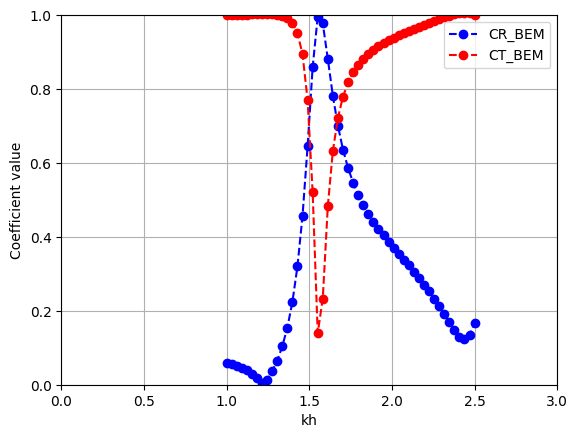

In [18]:
plt.figure(15)

plt.plot(kh, CR, 'b--o', label='CR_BEM')
plt.plot(kh, CT, 'r--o', label='CT_BEM')

plt.xlim([0, 3.00])
plt.ylim([0, 1.00])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("CR_CT.pdf")

# Optional: display the plot
plt.show()

**6.2 OWC performance**

<Figure size 640x480 with 0 Axes>

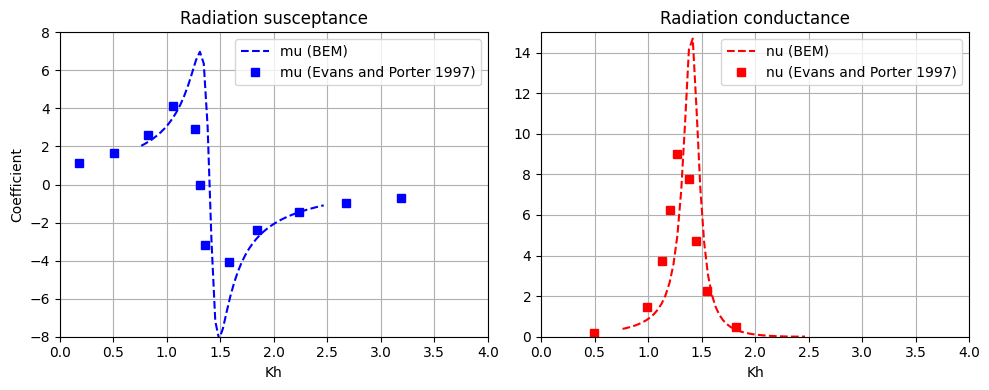

In [27]:
mu_bh_12 = np.array([
    [0.1820,  1.1570],     [0.5110,  1.6800],
    [0.8210,  2.6270],     [1.0550,  4.1240],
    [1.2640,  2.9180],     [1.3100, -0.0070],
    [1.3590, -3.1870],     [1.5820, -4.0540],
    [1.8470, -2.3970],     [2.2320, -1.4180],
    [2.6770, -0.9470],     [3.1890, -0.6870]
])

nu_bh_12 = np.array([
    [0.4982, 0.1753],    [0.9877, 1.4693],
    [1.1340, 3.7539],    [1.2072, 6.2487],
    [1.2684, 8.9998],    [1.3795, 7.7549],
    [1.4504, 4.7121],    [1.5544, 2.2775],
    [1.8175, 0.4744]])

plt.figure()

# Create figure with 2 plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# --- Horizontal force ---
ax1.plot(Kh, mu, 'b--', label='mu (BEM)')
ax1.plot(mu_bh_12[:,0], mu_bh_12[:,1], 'bs', label='mu (Evans and Porter 1997)')
ax1.set_xlim([0,4])
ax1.set_ylim([-8.0,8.0])
ax1.set_xlabel('Kh')
ax1.set_ylabel('Coefficient')
ax1.set_title('Radiation susceptance')
ax1.grid(True)
ax1.legend()

# --- Vertical force ---
ax2.plot(Kh, nu, 'r--', label='nu (BEM)')
ax2.plot(nu_bh_12[:,0], nu_bh_12[:,1], 'rs', label='nu (Evans and Porter 1997)')
ax2.set_xlim([0,4])
ax2.set_ylim([0,15.0])
ax2.set_xlabel('Kh')
ax2.set_title('Radiation conductance')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig("mu_nu_side_by_side.pdf")
plt.show()

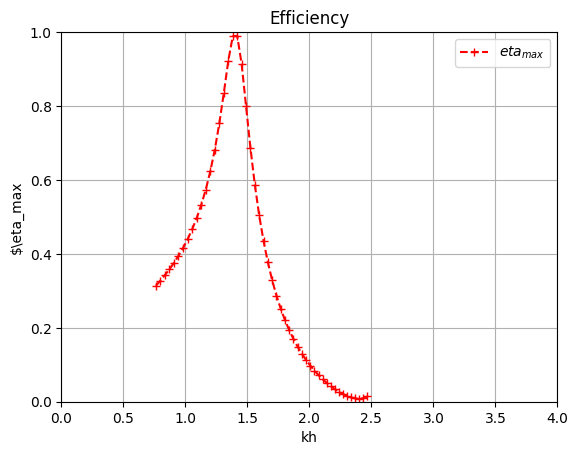

In [20]:
plt.figure()

plt.plot(Kh, eta, 'r--+', label=r'$eta_{max}$')

plt.xlim([0, 4])
plt.ylim([0, 1.0])

plt.xlabel('kh')
plt.ylabel(r'$\eta_max')

plt.title('Efficiency')

plt.legend()
plt.grid(True)

# Optional: display the plot
plt.show()